# Import Required Libraries
Import the necessary libraries, including pandas and numpy.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset
Load the dataset from df_final_demo.txt into a pandas DataFrame.

In [15]:
# Load the Dataset

# Load the dataset from df_final_demo.txt into a pandas DataFrame
df = pd.read_csv('../data/raw/df_final_demo.txt')

# Display the first few rows of the DataFrame to verify the data is loaded correctly
df.shape # (70609, 9)

(70609, 9)

# Inspect the Dataset
Inspect the first few rows, data types, and summary statistics of the dataset.

In [16]:
# Inspect the Dataset

# Display the first few rows of the DataFrame to verify the data is loaded correctly
df.head()

# Display the data types of each column
df.dtypes

# Display summary statistics of the dataset
df.describe(include='all').T

# Check for missing values in the dataset
df.isnull().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

# Categorical and Numerical Columns

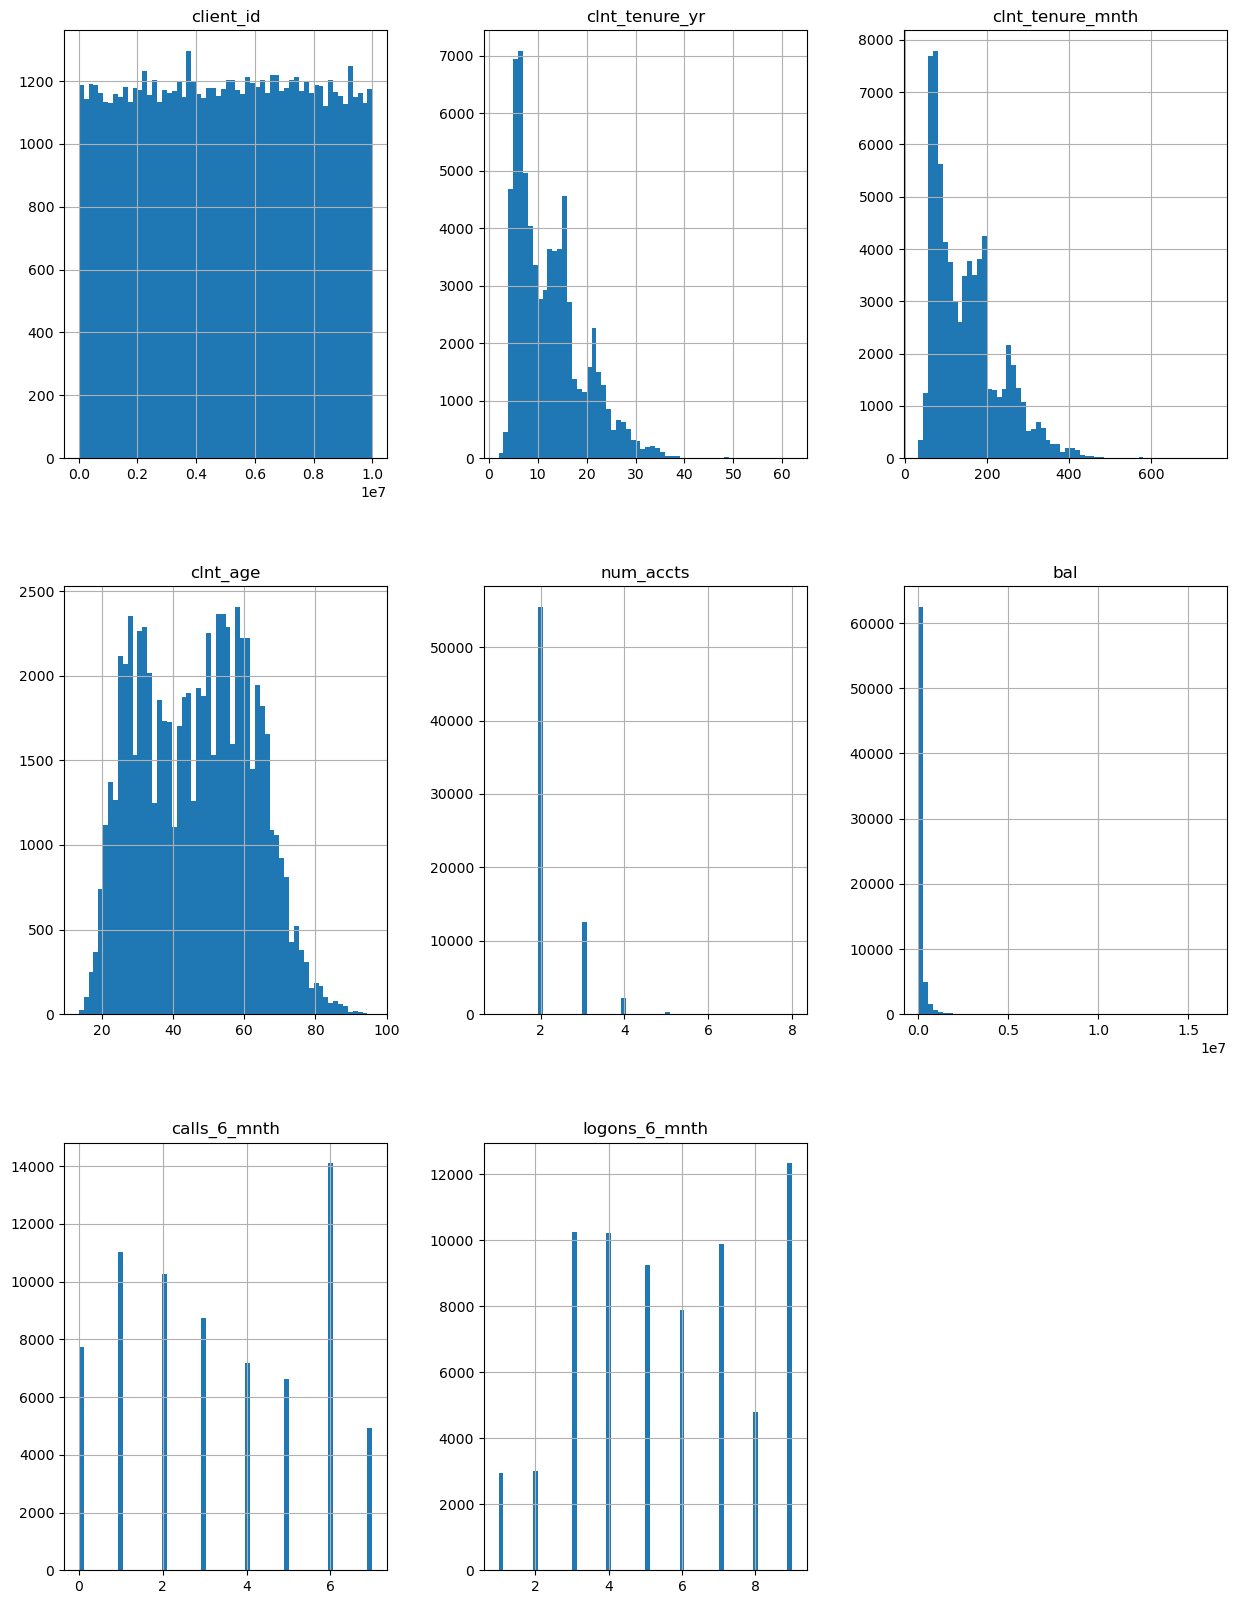

In [17]:
# Get numerical columns
df_numerical = df.select_dtypes(include=[np.number])

df_numerical.hist(figsize=(15, 20), bins=60, xlabelsize=10, ylabelsize=10)
plt.show()


# Handle Missing Values
Identify and handle missing values in the dataset, using methods such as filling with mean/median or dropping rows.

In [18]:
# Handle Missing Values

# Check for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Fill missing values in numerical columns with the mean
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Fill missing values in categorical columns with the mode
categorical_cols = df.select_dtypes(include=[object]).columns
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Verify that there are no missing values left
missing_values_after = df.isnull().sum()
print("Missing values after handling:\n", missing_values_after)

# Display the first few rows of the DataFrame to verify the changes
df.head()

Missing values in each column:
 client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64
Missing values after handling:
 client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


# Convert Data Types
Convert data types of columns to appropriate types, such as converting numerical columns to float or int.

In [19]:
# Convert Data Types

# Convert 'client_id' to string as it is an identifier
df['client_id'] = df['client_id'].astype(str)

# Convert 'clnt_tenure_yr' and 'clnt_tenure_mnth' to integers
df['clnt_tenure_yr'] = df['clnt_tenure_yr'].astype(int)
df['clnt_tenure_mnth'] = df['clnt_tenure_mnth'].astype(int)

# Convert 'clnt_age' to float
df['clnt_age'] = df['clnt_age'].astype(float)

# Convert 'num_accts' to integer
df['num_accts'] = df['num_accts'].astype(int)

# Convert 'bal' to float
df['bal'] = df['bal'].astype(float)

# Convert 'calls_6_mnth' and 'logons_6_mnth' to integers
df['calls_6_mnth'] = df['calls_6_mnth'].astype(int)
df['logons_6_mnth'] = df['logons_6_mnth'].astype(int)

# Verify the data types after conversion
df.dtypes

client_id            object
clnt_tenure_yr        int32
clnt_tenure_mnth      int32
clnt_age            float64
gendr                object
num_accts             int32
bal                 float64
calls_6_mnth          int32
logons_6_mnth         int32
dtype: object

# Normalize Column Names
Normalize column names to ensure consistency, such as converting to lowercase and replacing spaces with underscores.

In [20]:
# Normalize Column Names

# Normalize column names to ensure consistency
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Display the updated column names to verify the changes
df.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='object')

# Remove Duplicates
Remove duplicate rows from the dataset to ensure data integrity.

In [21]:
# Remove Duplicates

# Remove duplicate rows from the dataset
df = df.drop_duplicates()

# Verify that duplicates have been removed by checking the number of rows
df.shape

(70609, 9)

# Handle Outliers
Identify and handle outliers in the dataset using methods such as z-score or IQR.

In [22]:
import scipy.stats as stats

# Handle Outliers

# Calculate the z-scores of the numerical columns
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))

# Define a threshold for identifying outliers
threshold = 3

# Identify outliers
outliers = np.where(z_scores > threshold)

# Print the indices of the outliers
print("Indices of outliers:\n", outliers)

# Remove outliers from the dataset
df_cleaned = df[(z_scores < threshold).all(axis=1)]

# Verify the shape of the dataset after removing outliers
print("Shape of the dataset after removing outliers:", df_cleaned.shape)

# Display the first few rows of the cleaned DataFrame to verify the changes
df_cleaned.head()

Indices of outliers:
 (array([    7,    21,    86, ..., 70591, 70591, 70604], dtype=int64), array([3, 4, 3, ..., 0, 1, 4], dtype=int64))
Shape of the dataset after removing outliers: (66621, 9)


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6,73,60.5,U,2,45105.30,6,9
1,2304905,7,94,58.0,U,2,110860.30,6,9
2,1439522,5,64,32.0,U,2,52467.79,6,9
3,1562045,16,198,49.0,M,2,67454.65,3,6
4,5126305,12,145,33.0,F,2,103671.75,0,3


# Save Cleaned Dataset
Save the cleaned dataset to a new file for further analysis.

In [23]:
# Save Cleaned Dataset

# Save the cleaned dataset to a new CSV file
df_cleaned.to_csv('../data/processed/clients.csv', index=False)

# Verify that the file has been saved correctly by loading it back and displaying the first few rows
df_loaded = pd.read_csv('../data/processed/clients.csv')
#df_loaded.shape # (66621, 9)
df_loaded.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6,73,60.5,U,2,45105.30,6,9
1,2304905,7,94,58.0,U,2,110860.30,6,9
2,1439522,5,64,32.0,U,2,52467.79,6,9
3,1562045,16,198,49.0,M,2,67454.65,3,6
4,5126305,12,145,33.0,F,2,103671.75,0,3


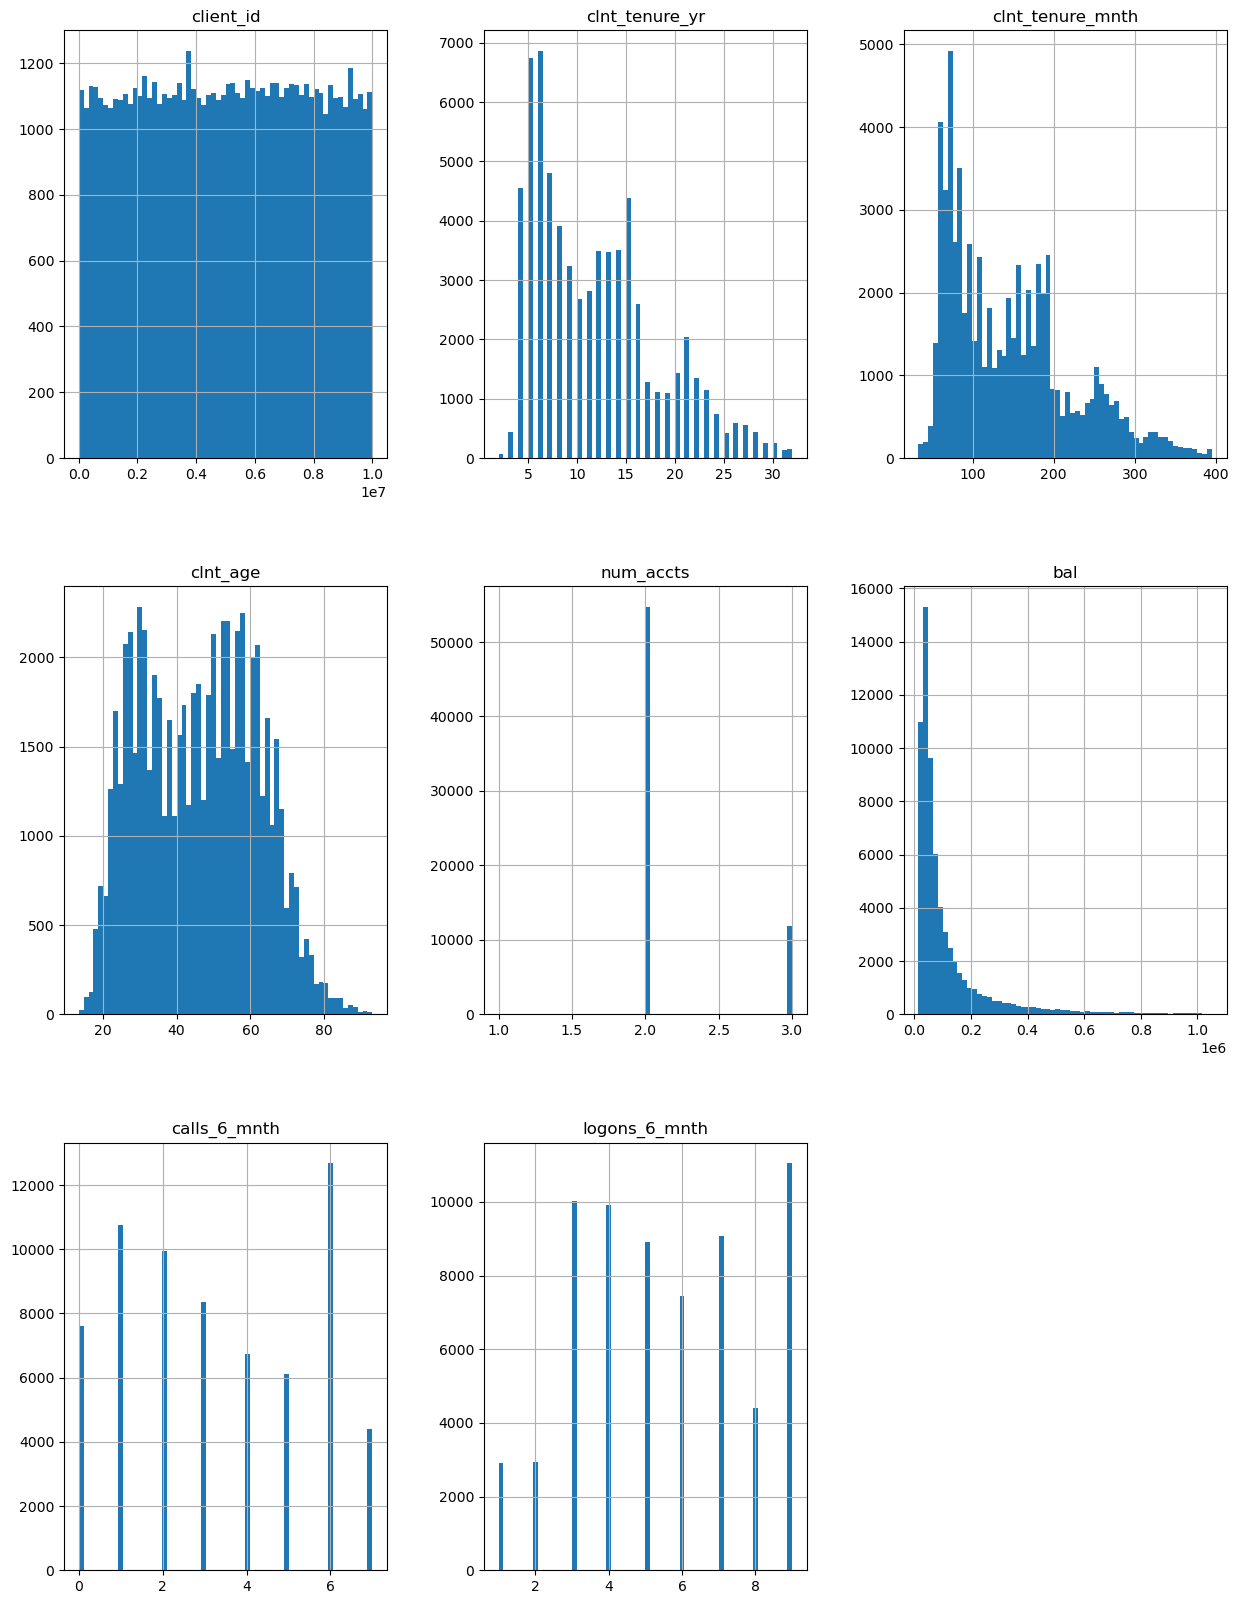

In [24]:
# Get numerical columns
df_numerical_loaded = df_loaded.select_dtypes(include=[np.number])

df_numerical_loaded.hist(figsize=(15, 20), bins=60, xlabelsize=10, ylabelsize=10)
plt.show()